In [1]:
!pip install python-louvain

In [2]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval
import community as community_louvain

In [3]:
df = pd.read_csv("vyfiltrovane_data3.csv")
df['Ncomb'] = df['Ncomb'].apply(literal_eval)
df['DatumZazmluvnenia'] = pd.to_datetime(df['DatumZazmluvnenia'], errors='coerce')
df['DatumZazmluvnenia_datum'] = df['DatumZazmluvnenia'].dt.date

In [4]:
df['OpisnyFormularKategoriaSluzieb'].value_counts()

OpisnyFormularKategoriaSluzieb
2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok                                                                                    41354
27. Ostatné služby                                                                                                                                                                                               2208
1. Opravy a údržba                                                                                                                                                                                               1599
3. Služby osobnej a nákladnej leteckej dopravy okrem prepravy poštových zásielok                                                                                                                                 1323
7. Počítačové a súvisiace služby                                                                                 

In [5]:
df['MiestoPlneniaKraj'].value_counts()

MiestoPlneniaKraj
Bratislavský       39656
Košický            23723
Žilinský           19865
Banskobystrický    16363
Prešovský          15918
Nitriansky         15848
Trenčiansky        13939
Trnavský           11996
Name: count, dtype: int64

In [31]:
selected_categories = [
    '21. Právnické služby',
    '1. Opravy a údržba'
]

#selected_regions = ['Bratislavský', 'Košický']
selected_regions = df['MiestoPlneniaKraj'].dropna().unique().tolist()


In [32]:
non_null_dates = df['DatumZazmluvnenia_datum'].dropna()

In [33]:
# start_date = non_null_dates.min()
# end_date = non_null_dates.max()
start_date = pd.to_datetime('2019-01-04').date()
end_date   = pd.to_datetime('2023-01-20').date()

In [34]:
filtered_df = df.copy()
if selected_categories:
    filtered_df = filtered_df[filtered_df['OpisnyFormularKategoriaSluzieb'].isin(selected_categories)]
if selected_regions:
    filtered_df = filtered_df[filtered_df['MiestoPlneniaKraj'].isin(selected_regions)]
filtered_df = filtered_df[(filtered_df['DatumZazmluvnenia_datum'] >= start_date) &
                          (filtered_df['DatumZazmluvnenia_datum'] <= end_date)]

In [35]:
G = nx.Graph()
for row in filtered_df.itertuples():
    suppliers = [str(s) for s in row.Ncomb]
    for s in suppliers:
        G.add_node(s)  # добавляем узел
    for i in range(len(suppliers)):
        for j in range(i+1, len(suppliers)):
            a, b = suppliers[i], suppliers[j]
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)


In [36]:
print(df['Ncomb'].head())

0                                           [35894725]
1                                           [35894725]
2                                   [41474589, 650951]
3    [31344194, 31344381, 36373583, 36523496, 36880...
4             [31344194, 35755989, 36365645, 36468924]
Name: Ncomb, dtype: object


In [37]:
partition = community_louvain.best_partition(G, weight='weight')

In [38]:
from collections import defaultdict
savings_data = defaultdict(lambda: {'sum': 0.0, 'count': 0})
for row in filtered_df.itertuples():
    for contractor in row.Ncomb:
        contractor = str(contractor)
        savings_data[contractor]['sum'] += row.Ncomb_savings_mean_noexpand
        savings_data[contractor]['count'] += 1
avg_savings = {k: v['sum']/v['count'] if v['count']>0 else 0 for k,v in savings_data.items()}


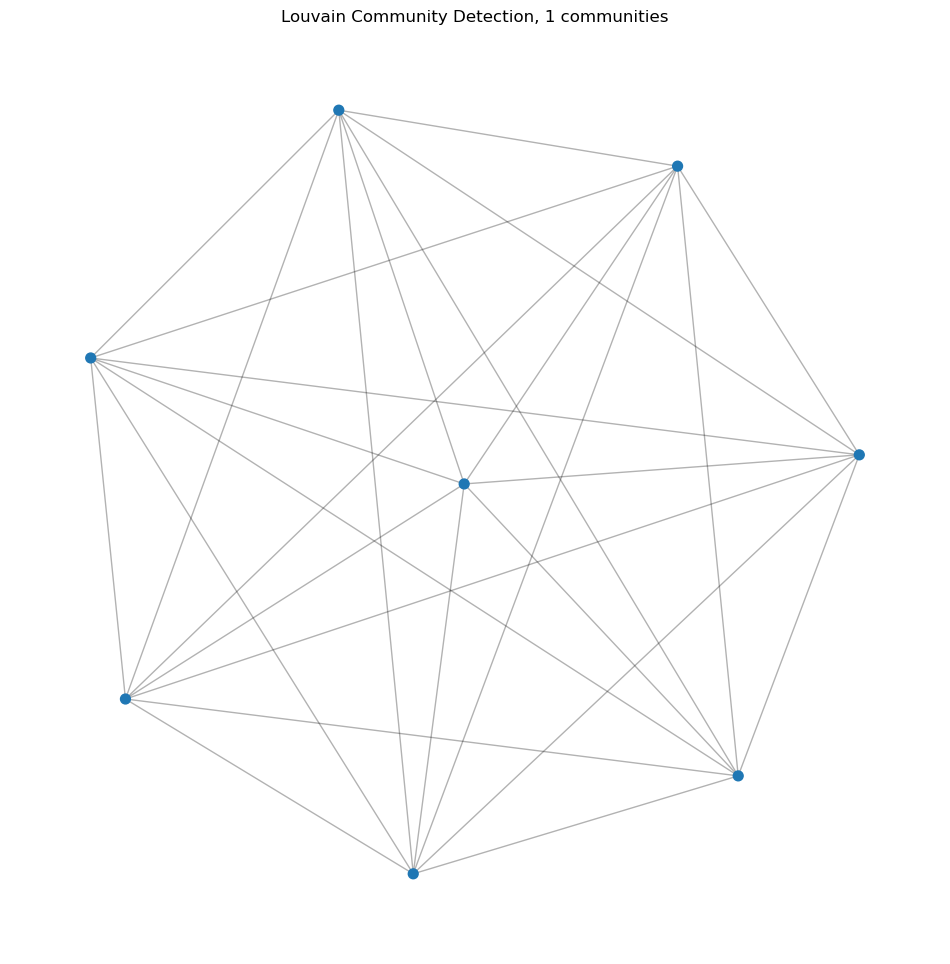

In [39]:
# --- 6. Визуализация ---
pos = nx.spring_layout(G, seed=42)
plt.figure(figsize=(12, 12))
# Цвет узлов по сообществам
colors = [partition[n] for n in G.nodes()]
nx.draw_networkx_nodes(G, pos, node_size=50, cmap=plt.cm.tab20, node_color=colors)
nx.draw_networkx_edges(G, pos, alpha=0.3)
plt.title(f"Louvain Community Detection, {len(set(partition.values()))} communities")
plt.axis('off')
plt.show()


In [41]:
!pip install plotly

   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 9.9/9.9 MB 82.0 MB/s eta 0:00:00


Количество узлов: 8249, количество рёбер: 185985
Найдено комьюнити: 54


/tmp/ipykernel_383/557494573.py:37: MatplotlibDeprecationWarning: The get_cmap function was deprecated in Matplotlib 3.7 and will be removed in 3.11. Use ``matplotlib.colormaps[name]`` or ``matplotlib.colormaps.get_cmap()`` or ``pyplot.get_cmap()`` instead.
  cmap = cm.get_cmap('viridis', num_communities)


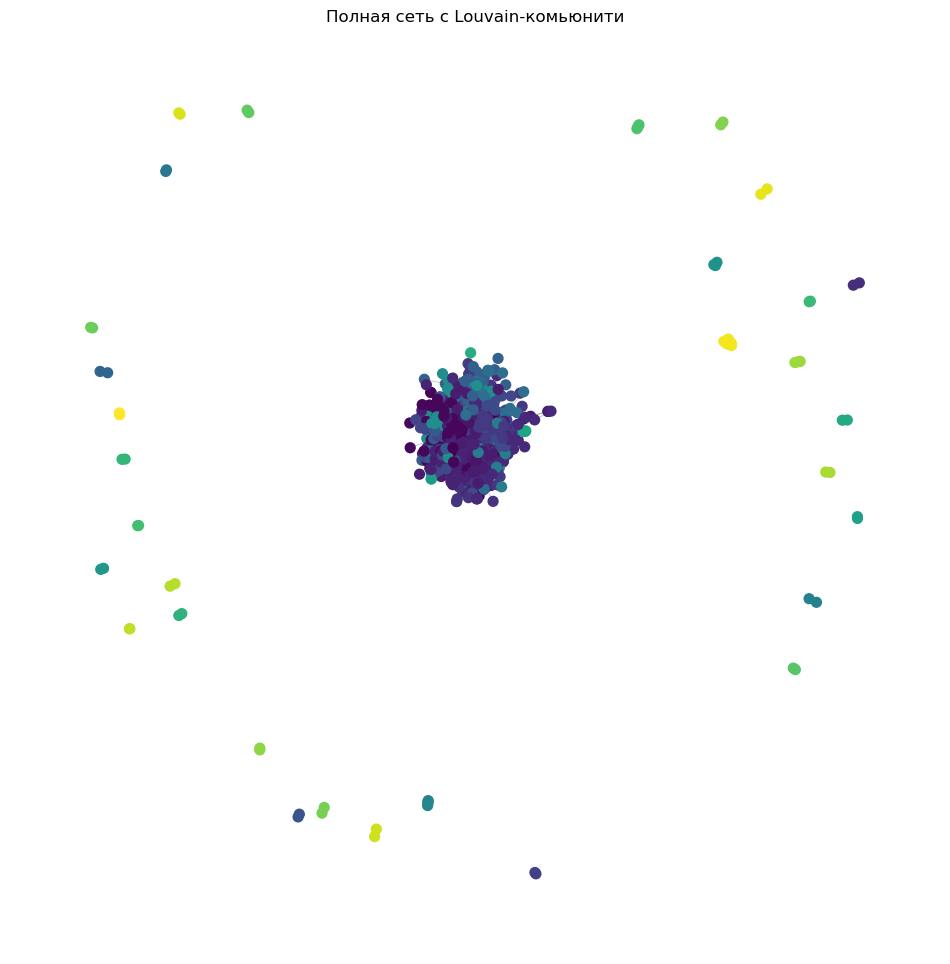

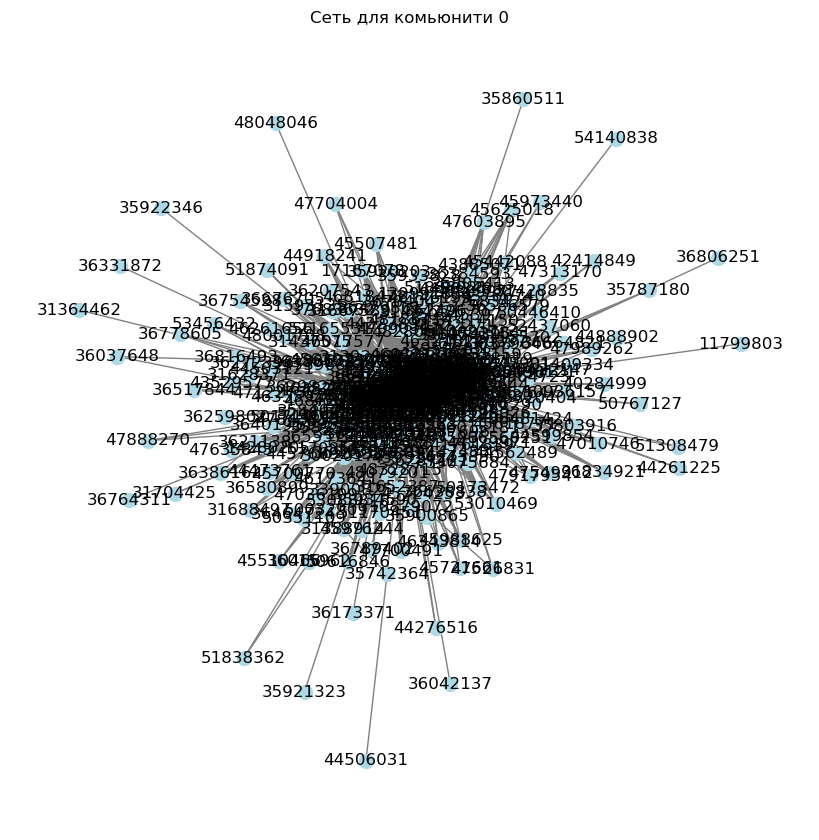

In [43]:
import pandas as pd
import networkx as nx
import matplotlib.pyplot as plt
from ast import literal_eval
import community as community_louvain  # pip install python-louvain
import matplotlib.cm as cm

# === 1. Загрузим данные ===
df = pd.read_csv("vyfiltrovane_data3.csv")
df['Ncomb'] = df['Ncomb'].apply(literal_eval)

# === 2. Построим полный граф ===
G = nx.Graph()
for row in df.itertuples():
    suppliers = [str(s) for s in row.Ncomb]
    for i in range(len(suppliers)):
        for j in range(i+1, len(suppliers)):
            a, b = suppliers[i], suppliers[j]
            if G.has_edge(a, b):
                G[a][b]['weight'] += 1
            else:
                G.add_edge(a, b, weight=1)

print(f"Количество узлов: {G.number_of_nodes()}, количество рёбер: {G.number_of_edges()}")

# === 3. Найдём комьюнити Louvain ===
partition = community_louvain.best_partition(G, weight='weight')

# Сколько комьюнити получилось
num_communities = len(set(partition.values()))
print(f"Найдено комьюнити: {num_communities}")

# === 4. Визуализируем сеть ===
pos = nx.spring_layout(G, seed=42)  # координаты для узлов

# Цвета для комьюнити
cmap = cm.get_cmap('viridis', num_communities)
colors = [cmap(partition[node]) for node in G.nodes()]

plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.3, width=0.5)
nx.draw_networkx_nodes(G, pos, node_color=colors, node_size=50)
plt.title("Полная сеть с Louvain-комьюнити")
plt.axis('off')
plt.show()

# === 5. Визуализация отдельной комьюнити (пример) ===
# Выберем комьюнити 0
community_id = 0
nodes_in_community = [n for n, c in partition.items() if c == community_id]
subG = G.subgraph(nodes_in_community)

plt.figure(figsize=(8, 8))
nx.draw(subG, with_labels=True, node_color='lightblue', node_size=100, edge_color='gray')
plt.title(f"Сеть для комьюнити {community_id}")
plt.show()


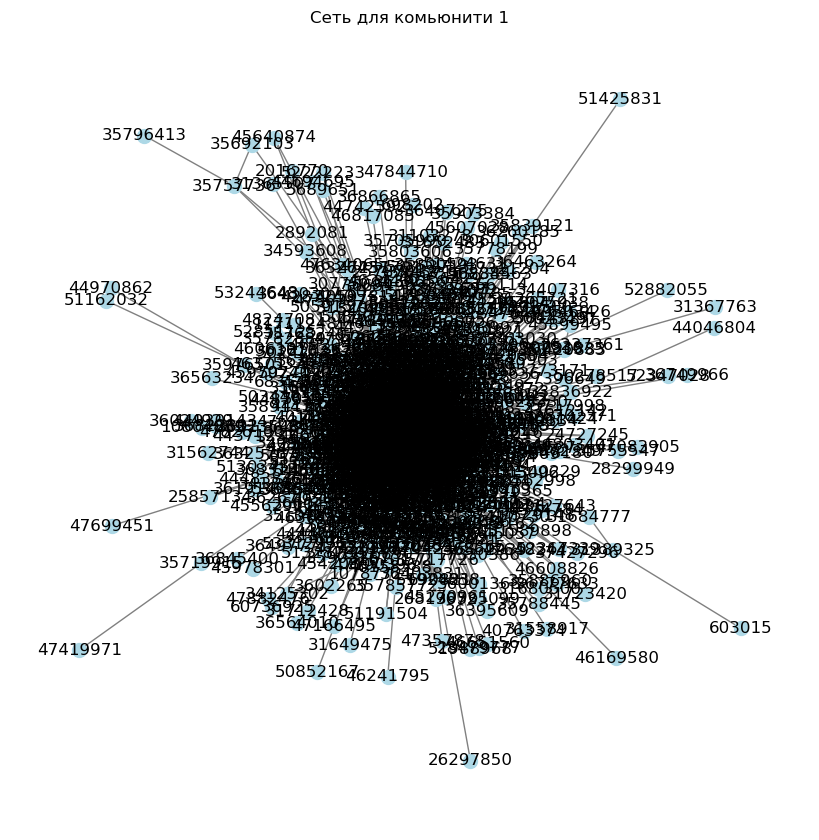

In [45]:
community_id = 1
nodes_in_community = [n for n, c in partition.items() if c == community_id]
subG = G.subgraph(nodes_in_community)

plt.figure(figsize=(8, 8))
nx.draw(subG, with_labels=True, node_color='lightblue', node_size=100, edge_color='gray')
plt.title(f"Сеть для комьюнити {community_id}")
plt.show()


In [48]:
from collections import defaultdict, Counter

community_stats = defaultdict(lambda: {
    "nodes": 0,
    "avg_savings": 0,
    "categories": Counter(),
    "regions": Counter()
})

for row in df.itertuples():
    for contractor in row.Ncomb:
        contractor = str(contractor)
        if contractor in partition:
            c = partition[contractor]
            community_stats[c]["nodes"] += 1
            community_stats[c]["avg_savings"] += row.Ncomb_savings_mean_noexpand
            community_stats[c]["categories"][row.OpisnyFormularKategoriaSluzieb] += 1
            community_stats[c]["regions"][row.MiestoPlneniaKraj] += 1

# Посчитаем среднюю экономию
for c, stats in community_stats.items():
    if stats["nodes"] > 0:
        stats["avg_savings"] /= stats["nodes"]

# Выведем
for c, stats in community_stats.items():
    print(f"Комьюнити {c}: узлы={stats['nodes']}, средняя экономия={stats['avg_savings']:.2f}, "
          f"топ категории={stats['categories'].most_common(3)}, топ регионы={stats['regions'].most_common(3)}")


Комьюнити 11: узлы=17317, средняя экономия=nan, топ категории=[(nan, 11467), ('15. Tlačiarenské a publikačné služby za poplatok alebo na základe zmluvy', 2804), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 2246)], топ регионы=[('Bratislavský', 5700), ('Prešovský', 2195), ('Nitriansky', 2049)]
Комьюнити 0: узлы=69022, средняя экономия=nan, топ категории=[(nan, 37841), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 30214), ('27. Ostatné služby', 403)], топ регионы=[('Bratislavský', 20548), ('Trenčiansky', 8180), ('Nitriansky', 7339)]
Комьюнити 1: узлы=135548, средняя экономия=nan, топ категории=[(nan, 88733), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 43757), ('7. Počítačové a súvisiace služby ', 1704)], топ регионы=[('Bratislavský', 50352)

In [49]:
for c, stats in community_stats.items():
    stats["total_savings"] = stats["avg_savings"] * stats["nodes"]

# Отсортируем
top_savings = sorted(community_stats.items(), key=lambda x: x[1]["total_savings"], reverse=True)
for c, stats in top_savings[:10]:
    print(f"Комьюнити {c}: узлы={stats['nodes']}, общая экономия={stats['total_savings']:.2f}")


Комьюнити 11: узлы=17317, общая экономия=nan
Комьюнити 0: узлы=69022, общая экономия=nan
Комьюнити 1: узлы=135548, общая экономия=nan
Комьюнити 4: узлы=70865, общая экономия=nan
Комьюнити 2: узлы=8056, общая экономия=nan
Комьюнити 12: узлы=26163, общая экономия=nan
Комьюнити 9: узлы=9096, общая экономия=nan
Комьюнити 3: узлы=25442, общая экономия=nan
Комьюнити 5: узлы=51707, общая экономия=nan
Комьюнити 6: узлы=21226, общая экономия=nan


In [50]:
for c, stats in community_stats.items():
    print(f"Комьюнити {c}: топ категории {stats['categories'].most_common(3)}, топ регионы {stats['regions'].most_common(3)}")


Комьюнити 11: топ категории [(nan, 11467), ('15. Tlačiarenské a publikačné služby za poplatok alebo na základe zmluvy', 2804), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 2246)], топ регионы [('Bratislavský', 5700), ('Prešovský', 2195), ('Nitriansky', 2049)]
Комьюнити 0: топ категории [(nan, 37841), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 30214), ('27. Ostatné služby', 403)], топ регионы [('Bratislavský', 20548), ('Trenčiansky', 8180), ('Nitriansky', 7339)]
Комьюнити 1: топ категории [(nan, 88733), ('2. Služby pozemnej dopravy, vrátane služieb pancierových automobilov a kuriérskych služieb okrem prepravy poštových zásielok', 43757), ('7. Počítačové a súvisiace služby ', 1704)], топ регионы [('Bratislavský', 50352), ('Žilinský', 17040), ('Banskobystrický', 12717)]
Комьюнити 4: топ категории [(nan, 50698), ('2. Služb

In [51]:
degree_dict = dict(G.degree())
sorted_degree = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)
print("Топ 10 ключевых узлов по степени:")
print(sorted_degree[:10])


Топ 10 ключевых узлов по степени:
[('31344194', 1651), ('36556050', 1200), ('36426041', 1027), ('43959954', 1014), ('36645095', 936), ('43902138', 905), ('32529597', 893), ('37212931', 875), ('36428353', 857), ('43798608', 817)]


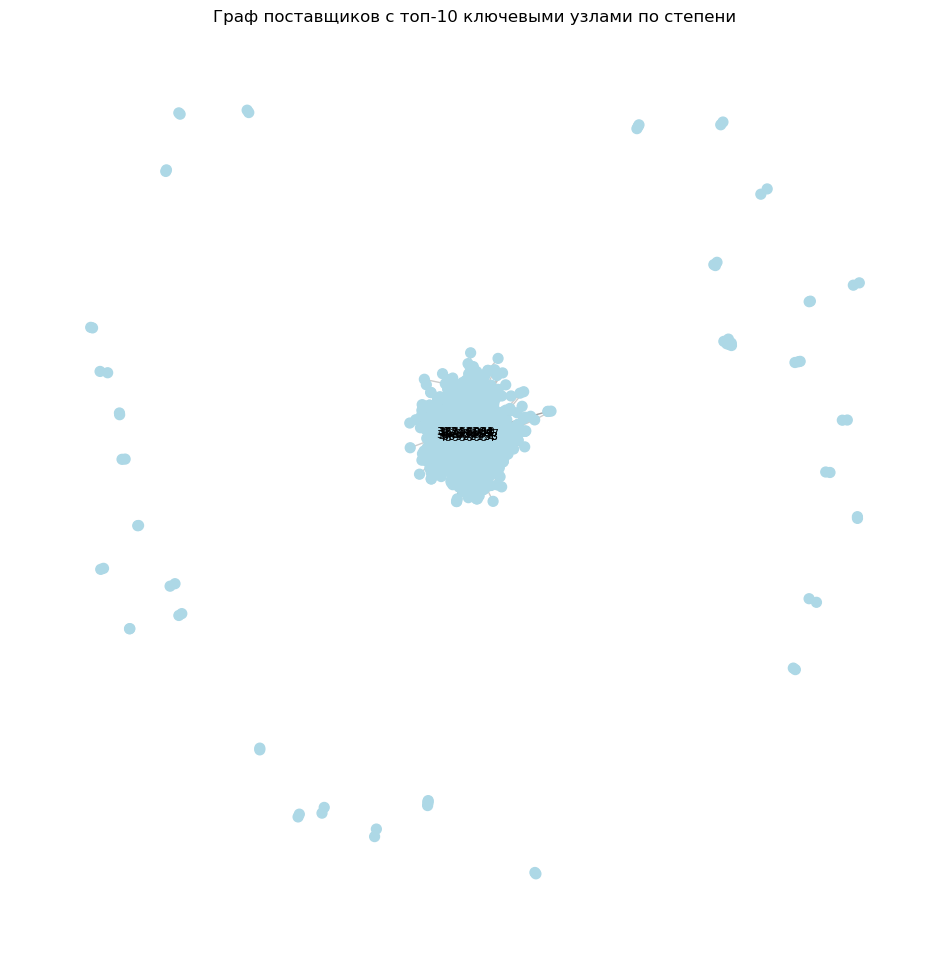

In [52]:
import networkx as nx
import matplotlib.pyplot as plt

# Предположим, G — твой граф, а degree_dict — степени всех узлов
degree_dict = dict(G.degree(weight=None))  # или weight='weight', если хочешь учитывать веса
top_nodes = sorted(degree_dict.items(), key=lambda x: x[1], reverse=True)[:10]  # топ 10

# Позиции узлов
pos = nx.spring_layout(G, seed=42)

# Цвет и размер для всех узлов
node_color = ['lightblue'] * G.number_of_nodes()
node_size = [50] * G.number_of_nodes()

# Отметим топ-узлы
top_node_ids = [n for n, d in top_nodes]
for i, n in enumerate(G.nodes()):
    if n in top_node_ids:
        node_color[i] = 'red'  # топ-узлы красные
        node_size[i] = 300      # больше размером

# Рисуем граф
plt.figure(figsize=(12, 12))
nx.draw_networkx_edges(G, pos, alpha=0.2)
nx.draw_networkx_nodes(G, pos, node_color=node_color, node_size=node_size)
nx.draw_networkx_labels(G, pos, labels={n:n for n in top_node_ids}, font_size=8, font_color='black')

plt.title("Граф поставщиков с топ-10 ключевыми узлами по степени")
plt.axis('off')
plt.show()


In [53]:
import networkx as nx
import community as community_louvain

# partition — это словарь node -> community, который вернул Louvain
modularity = community_louvain.modularity(partition, G, weight='weight')
print(f"Modularity всей сети: {modularity:.4f}")


Modularity всей сети: 0.6949


In [54]:
from collections import defaultdict

community_nodes = defaultdict(list)
for node, c in partition.items():
    community_nodes[c].append(node)

community_density = {}
for c, nodes in community_nodes.items():
    subG = G.subgraph(nodes)
    community_density[c] = nx.density(subG)

# Пример: топ-5 комьюнити по плотности
top5_density = sorted(community_density.items(), key=lambda x: x[1], reverse=True)[:5]
print("Топ-5 комьюнити по плотности:", top5_density)


Топ-5 комьюнити по плотности: [(28, 1.0), (30, 1.0), (32, 1.0), (34, 1.0), (35, 1.0)]


In [55]:
community_sizes = {c: len(nodes) for c, nodes in community_nodes.items()}
top5_size = sorted(community_sizes.items(), key=lambda x: x[1], reverse=True)[:5]
print("Топ-5 крупнейших комьюнити:", top5_size)


Топ-5 крупнейших комьюнити: [(4, 1295), (6, 1218), (1, 1081), (5, 813), (9, 538)]


In [56]:
def conductance(G, nodes):
    cut_edges = nx.cut_size(G, nodes, weight='weight')
    volume = sum(dict(G.degree(nodes, weight='weight')).values())
    if volume == 0:
        return 0
    return cut_edges / volume

community_conductance = {c: conductance(G, nodes) for c, nodes in community_nodes.items()}
top5_lowest_conductance = sorted(community_conductance.items(), key=lambda x: x[1])[:5]
print("Топ-5 наиболее «изолированных» комьюнити по conductance:", top5_lowest_conductance)


Топ-5 наиболее «изолированных» комьюнити по conductance: [(27, 0.0), (28, 0.0), (30, 0.0), (32, 0.0), (34, 0.0)]


In [57]:
top_nodes_degree = {}
for c, nodes in community_nodes.items():
    subG = G.subgraph(nodes)
    deg = dict(subG.degree(weight='weight'))
    top_nodes_degree[c] = sorted(deg.items(), key=lambda x: x[1], reverse=True)[:5]

# Топ-5 узлов для первой комьюнити
first_c = list(top_nodes_degree.keys())[0]
print(f"Топ узлы комьюнити {first_c} по степени:", top_nodes_degree[first_c])


Топ узлы комьюнити 0 по степени: [('36645095', 15324), ('36880574', 13501), ('32627211', 12588), ('33768897', 12183), ('36466778', 9680)]
